In [1]:
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers

In [2]:
IMG_SIZE = 224
batch_size = 32
NUM_CLASSES = 2
LEARNING_RATE = 0.001

In [3]:
train_dir = 'D:/Zuyyina Hawani_09040620070/trypo_split/trypo_train'
validation_dir = 'D:/Zuyyina Hawani_09040620070/trypo_split/trypo_valid'
test_dir = 'D:/Zuyyina Hawani_09040620070/trypophobia/tes'

In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=batch_size,
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    validation_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=batch_size,
    seed=123
)
test_gen = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=batch_size,
    color_mode='rgb',
    shuffle='False',
    seed=123
)

class_names = train_ds.class_names
print(class_names)

Found 12706 files belonging to 2 classes.
Found 3178 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
['1. Trypophobia', '2. Normal']


In [5]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomZoom(height_factor=-0.3, width_factor=0.3, fill_mode='nearest'),
    ],
    name="img_augmentation",
)

In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
outputs = EfficientNetB0(include_top=True, weights=None, classes=NUM_CLASSES)(x)


model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)
    
model.summary()
epochs = 15
model.fit(train_ds, epochs=epochs, validation_data=val_ds, verbose=2)



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 img_augmentation (Sequenti  (None, 224, 224, 3)       0         
 al)                                                             
                                                                 
 efficientnetb0 (Functional  (None, 2)                 4052133   
 )                                                               
                                                                 
Total params: 4052133 (15.46 MB)
Trainable params: 4010110 (15.30 MB)
Non-trainable params: 42023 (164.16 KB)
_________________________________________________________________
Epoch 1/15


398/398 - 2234s - loss: 0.8730 - accuracy: 0.6840 - val_loss: 0.5281 - val_accuracy: 0.7587 - 2234s/epoch - 6s/step
Epoch 2/15
398/398

In [7]:
def build_model(num_classes, input_shape):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    model = EfficientNetB0(include_top=False, input_tensor=x, weights="imagenet")

    # Freeze the pretrained weights
    model.trainable = False

    # Rebuild top
    x = layers.GlobalAveragePooling2D(name="avg_pool")(model.output)
    x = layers.BatchNormalization()(x)

    top_dropout_rate = 0.2
    x = layers.Dropout(top_dropout_rate, name="top_dropout")(x)
    outputs = layers.Dense(num_classes, activation="sigmoid", name="pred")(x)

    # Compile
    model = tf.keras.Model(inputs, outputs, name="EfficientNet")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='binary_crossentropy',
              metrics=['accuracy'])
    return model

In [8]:
model = build_model(num_classes=NUM_CLASSES, input_shape=(IMG_SIZE, IMG_SIZE, 3))

epochs = 15
model.fit(train_ds, epochs=epochs, validation_data=val_ds, verbose=2)

Epoch 1/15
398/398 - 617s - loss: 0.2719 - accuracy: 0.8985 - val_loss: 0.1808 - val_accuracy: 0.9371 - 617s/epoch - 2s/step
Epoch 2/15
398/398 - 528s - loss: 0.2068 - accuracy: 0.9230 - val_loss: 0.1738 - val_accuracy: 0.9358 - 528s/epoch - 1s/step
Epoch 3/15
398/398 - 531s - loss: 0.1904 - accuracy: 0.9290 - val_loss: 0.1699 - val_accuracy: 0.9386 - 531s/epoch - 1s/step
Epoch 4/15
398/398 - 531s - loss: 0.1836 - accuracy: 0.9331 - val_loss: 0.1693 - val_accuracy: 0.9383 - 531s/epoch - 1s/step
Epoch 5/15
398/398 - 529s - loss: 0.1850 - accuracy: 0.9295 - val_loss: 0.1678 - val_accuracy: 0.9355 - 529s/epoch - 1s/step
Epoch 6/15
398/398 - 464s - loss: 0.1775 - accuracy: 0.9326 - val_loss: 0.1688 - val_accuracy: 0.9361 - 464s/epoch - 1s/step
Epoch 7/15
398/398 - 520s - loss: 0.1773 - accuracy: 0.9337 - val_loss: 0.1697 - val_accuracy: 0.9336 - 520s/epoch - 1s/step
Epoch 8/15
398/398 - 531s - loss: 0.1773 - accuracy: 0.9321 - val_loss: 0.1689 - val_accuracy: 0.9339 - 531s/epoch - 1s/step


In [9]:
# Evaluasi model pada dataset pengujian
test_loss, test_accuracy = model.evaluate(test_gen)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

32/32 [==============================] - 34s 1s/step - loss: 0.1718 - accuracy: 0.9350
Test Loss: 0.17175810039043427
Test Accuracy: 0.9350000023841858


In [10]:
def unfreeze_model(model):
    # We unfreeze the top 10 layers while leaving BatchNorm layers frozen
    for layer in model.layers[-10:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='binary_crossentropy',
              metrics=['accuracy'])

unfreeze_model(model)

epochs = 15

model.fit(train_ds, epochs=epochs, validation_data=val_ds, verbose=2)

Epoch 1/15
398/398 - 651s - loss: 0.2257 - accuracy: 0.9259 - val_loss: 0.1534 - val_accuracy: 0.9484 - 651s/epoch - 2s/step
Epoch 2/15
398/398 - 562s - loss: 0.1267 - accuracy: 0.9541 - val_loss: 0.1549 - val_accuracy: 0.9418 - 562s/epoch - 1s/step
Epoch 3/15
398/398 - 560s - loss: 0.0902 - accuracy: 0.9664 - val_loss: 0.1704 - val_accuracy: 0.9402 - 560s/epoch - 1s/step
Epoch 4/15
398/398 - 561s - loss: 0.0797 - accuracy: 0.9695 - val_loss: 0.1623 - val_accuracy: 0.9437 - 561s/epoch - 1s/step
Epoch 5/15
398/398 - 560s - loss: 0.0676 - accuracy: 0.9756 - val_loss: 0.1793 - val_accuracy: 0.9412 - 560s/epoch - 1s/step
Epoch 6/15
398/398 - 509s - loss: 0.0659 - accuracy: 0.9758 - val_loss: 0.1693 - val_accuracy: 0.9484 - 509s/epoch - 1s/step
Epoch 7/15
398/398 - 352s - loss: 0.0554 - accuracy: 0.9795 - val_loss: 0.1951 - val_accuracy: 0.9475 - 352s/epoch - 884ms/step
Epoch 8/15
398/398 - 198s - loss: 0.0406 - accuracy: 0.9854 - val_loss: 0.2092 - val_accuracy: 0.9475 - 198s/epoch - 498ms

In [11]:
# Evaluasi model pada dataset pengujian
test_loss, test_accuracy = model.evaluate(test_gen)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

32/32 [==============================] - 12s 367ms/step - loss: 0.2829 - accuracy: 0.9350
Test Loss: 0.2829163372516632
Test Accuracy: 0.9350000023841858


1/1 [==============================] - 1s 1s/step
Accuracy: 0.935
Precision: 0.9356290483458114
Recall: 0.935
F1-score: 0.9353144184058586


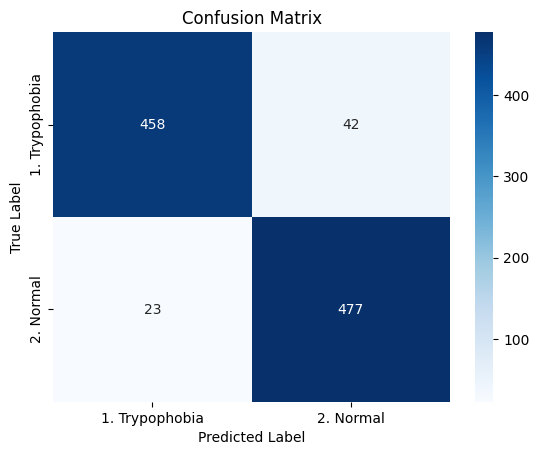

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt

test_ds = test_gen.batch(batch_size)
y_true = []
y_pred = []
for x, y in test_gen:
    y_true.extend(np.argmax(y, axis=1))
    y_pred.extend(np.argmax(model.predict(x), axis=1))

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Calculate accuracy, precision, and recall
TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)
accuracy = np.mean((TP + TN) / (TP + TN + FP + FN))
precision = np.mean(TP / (TP + FP))
recall = np.mean(TP / (TP + FN))
f1_score = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1_score)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [13]:
model.save('implementation3_10layers.h5',save_format='h5')

C:\Users\User\.conda\envs\zuyyinapy\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
